In [19]:
# Generate sets of differential equations for single qubits and multiple qubits in a cavity up to n'th operator order using the hierarchical equations of motion approach
# Finally use cumulants to make the problem solvable
include("operator_terms.jl")
include("combinatorics.jl")
include("cumulants.jl")
include("diff_Eq.jl")
include("preprocessing.jl")
include("indexing.jl")
include("initial_states.jl")
include("pulses.jl")
include("diff_Eq_solver.jl")
include("plotting.jl")
println("Included all files")
#using ForwardDiff
#using Optimization, Ipopt, OptimizationOptimJL 
using Random
rng = MersenneTwister(1234)

Included all files


MersenneTwister(1234)

In [8]:
############################################################################
#### Single Qubit in a cavity ##############################################
############################################################################

In [9]:
n = 2
all_eqs = single_spin_gen_DE_up_to_order(n)
conjugate_to_basis!(all_eqs)           # Add this line to replace terms outside of the basis with conjugate versions in the basis
for eqs in all_eqs
    for eq in eqs
        display(eq)
    end
end

d/dt⟨a⟩ =  - κ/2⟨a⟩ - g/2(i⟨x⟩ + ⟨y⟩) + β√̅κ

d/dt⟨x⟩ = ig(⟨az⟩ - ⟨az⟩*) - 2γ⟨x⟩ - Δ⟨y⟩ - Γ/2⟨x⟩

d/dt⟨y⟩ =  - g(⟨az⟩ + ⟨az⟩*) - 2γ⟨y⟩ + Δ⟨x⟩ - Γ/2⟨y⟩

d/dt⟨z⟩ = g(⟨ay⟩ - i⟨ax⟩ + ⟨ay⟩* + i⟨ax⟩*) - Γ(⟨z⟩ + 1)

d/dt⟨a²⟩ =  - κ⟨a²⟩ - g(i⟨ax⟩ + ⟨ay⟩) + 2β√̅κ⟨a⟩

d/dt⟨a†a⟩ =  - κ⟨a†a⟩ + g/2( - i⟨ax⟩* - ⟨ay⟩* + i⟨ax⟩ - ⟨ay⟩) + β√̅κ⟨a⟩* + β*√̅κ⟨a⟩

d/dt⟨ax⟩ =  - κ/2⟨ax⟩ + ig/2(2⟨a²z⟩ - 1 - 2⟨a†az⟩ - ⟨z⟩) + β√̅κ⟨x⟩ - 2γ⟨ax⟩ - Δ⟨ay⟩ - Γ/2⟨ax⟩

d/dt⟨ay⟩ =  - κ/2⟨ay⟩ - g/2(2⟨a²z⟩ + 2⟨a†az⟩ + ⟨z⟩ + 1) + β√̅κ⟨y⟩ - 2γ⟨ay⟩ + Δ⟨ax⟩ - Γ/2⟨ay⟩

d/dt⟨az⟩ =  - κ/2⟨az⟩ + g/2(2⟨a²y⟩ - 2i⟨a²x⟩ + 2⟨a†ay⟩ + ⟨y⟩ + 2i⟨a†ax⟩ + i⟨x⟩) + β√̅κ⟨z⟩ - Γ(⟨az⟩ + ⟨a⟩)

In [10]:
#### Calculate Cumulant terms from cumulant_indexed_vector and an operator expectation value vector
# Test
p::Float64 = 0.1
alpha::Float64 = 0.1
Theta::Float64 = 0.1
all_eqs = single_spin_gen_DE_up_to_order(3)
conjugate_to_basis!(all_eqs)
all_eqs_indexed, op_index_dicts, vars_dict, cumulant_terms_dict = parse_DE_to_indexes(all_eqs)
cumulant_vector = cumulant_terms_from_dict(cumulant_terms_dict, op_index_dicts)
lower_cumulants = lower_order_full_cumulant_terms(op_index_dicts, 2)
op_index_vec, vars_vec, cumulant_terms_vec = preprocess_index_inversion(op_index_dicts, vars_dict, cumulant_terms_dict)
initial_conditions = term_str2coherent_gibbs_states(op_index_vec, p, alpha, Theta)
display(cumulant_vector)
display(lower_cumulants)
display(get_cumulant_values_provided(cumulant_vector, initial_conditions))

6-element Vector{Cumulant_indexed}:
 Cumulant_indexed([[1, 1, 1, 4], [5, 1, 4], [9, 1, 1], [5, 9], [9, 5], [10, 4], [16, 1]], [6, -6, -6, 2, 1, 1, 3], "---z")
 Cumulant_indexed([[-1, 1, 1, 4], [6, 1, 4], [-9, 1, 1], [5, -1, 4], [9, -1, 1], [6, 9], [-9, 5], [11, 4], [17, 1], [16, -1]], [6, -4, -2, -2, -4, 2, 1, 1, 2, 1], "+--z")
 Cumulant_indexed([[1, 1, 1, 3], [5, 1, 3], [8, 1, 1], [5, 8], [8, 5], [10, 3], [14, 1]], [6, -6, -6, 2, 1, 1, 3], "---y")
 Cumulant_indexed([[1, 1, 1, 2], [5, 1, 2], [7, 1, 1], [5, 7], [7, 5], [10, 2], [12, 1]], [6, -6, -6, 2, 1, 1, 3], "---x")
 Cumulant_indexed([[-1, 1, 1, 3], [6, 1, 3], [-8, 1, 1], [5, -1, 3], [8, -1, 1], [6, 8], [-8, 5], [11, 3], [15, 1], [14, -1]], [6, -4, -2, -2, -4, 2, 1, 1, 2, 1], "+--y")
 Cumulant_indexed([[-1, 1, 1, 2], [6, 1, 2], [-7, 1, 1], [5, -1, 2], [7, -1, 1], [6, 7], [-7, 5], [11, 2], [13, 1], [12, -1]], [6, -4, -2, -2, -4, 2, 1, 1, 2, 1], "+--x")

3-element Vector{Vector{Vector{Full_Cumulant_indexed}}}:
 [[Full_Cumulant_indexed([[1]], [1], "-")], [Full_Cumulant_indexed([[4]], [1], "z"), Full_Cumulant_indexed([[3]], [1], "y")]]
 [[Full_Cumulant_indexed([[-1, 1], [6]], [-1, 1], "+-"), Full_Cumulant_indexed([[1, 1], [5]], [-1, 1], "--")], [Full_Cumulant_indexed([[1, 4], [9]], [-1, 1], "-z"), Full_Cumulant_indexed([[1, 3], [8]], [-1, 1], "-y")]]
 [[Full_Cumulant_indexed([[-1, 1, 1], [6, 1], [5, -1], [11]], [2, -2, -1, 1], "+--"), Full_Cumulant_indexed([[1, 1, 1], [5, 1], [10]], [2, -3, 1], "---")], [Full_Cumulant_indexed([[-1, 1, 4], [6, 4], [-9, 1], [9, -1], [17]], [2, -1, -1, -1, 1], "+-z"), Full_Cumulant_indexed([[-1, 1, 3], [6, 3], [-8, 1], [8, -1], [15]], [2, -1, -1, -1, 1], "+-y")]]

6-element Vector{ComplexF64}:
 0.0007642691913004843 - 0.00023641616532907176im
 0.0007960033322224217 - 7.986673331746262e-5im
                   0.0 + 0.0im
                   0.0 + 0.0im
                   0.0 + 0.0im
                   0.0 + 0.0im

In [11]:
how_many::Int = 10
max_A::Float64 =  0.1
T::Float64 = 10.0
n = 10
pulse_param::Pulse_Param_Struct = Random_Pulse_Param_Wurst(how_many, max_A, T, n, rng=rng)
val_dict::Dict = Dict("\\beta" => wurst_pulse_generator(pulse_param), "\\Delta" => 0.1, "g" => 0.2, "\\gamma" => 0.1, "\\Gamma" => 0.1, "\\kappa" => 0.1)

Dict{String, Any} with 6 entries:
  "g"       => 0.2
  "\\Gamma" => 0.1
  "\\gamma" => 0.1
  "\\beta"  => fun
  "\\Delta" => 0.1
  "\\kappa" => 0.1

In [13]:
param_generator, constant_value_indexes = value_generator(pulse_param, val_dict, vars_vec)
all_eqs_indexed_reduced = remove_zero_terms(all_eqs_indexed, param_generator, constant_value_indexes; how_many_eps=5)
diff_problem = DifferentialProblem(param_generator, all_eqs_indexed_reduced, cumulant_vector, Full_Cumulant_indexed[])
#d_initial_conditions = zeros(ComplexF64, length(op_index_vec))
solution = evolve_system(initial_conditions, diff_problem, T, dt=0.01, autodiff=true, reltol=1e-10)
println("Done")

Done


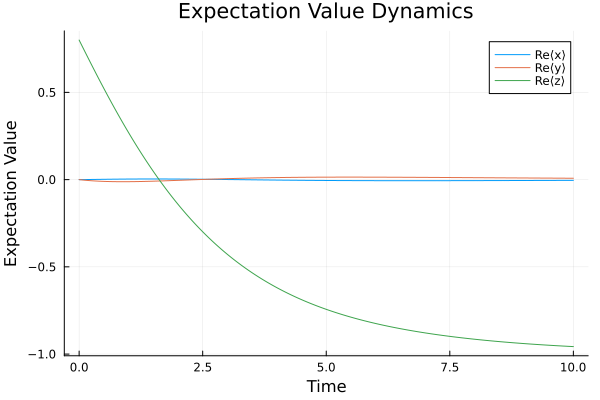

In [18]:
# Test 
plt = plot_expectation_values_over_t(solution, op_index_vec, ["x", "y", "z"], do_real=true, xlabel="Time", ylabel="Expectation Value", title="Expectation Value Dynamics")
display(plt)

In [ ]:
# Loss functions # figure out what states to use and how
function gate2optimum(gate::Matrix{ComplexF64,2,2}, initial_state)
    
    

In [ ]:
function Optimize_Problem()

optimization_problem = OptimizationFunction((x, p) -> -P_s(x, ws, p, n, max_delta), Optimization.AutoForwardDiff(), cons=(res, x, p) -> f_constraint(res, x, ws, p, n))
problem = OptimizationProblem(optimization_problem, coeff, param, lcons=[0.0], ucons=[0.0])

ErrorException: syntax: incomplete: "function" at c:\Users\micha\Desktop\PhD\Research\Projects\DD_Inhomogenously_Broadened_Spin_Ensemble\Julia\test_DE_derivations.ipynb:1 requires end

In [ ]:
# Example optimization - For a harmonic OScillator
using DifferentialEquations
using ForwardDiff
using DiffEqSensitivity
using Zygote
# Define the ODE function
function harmonic_oscillator(du, u, k, t)
    du[1] = u[2]
    du[2] = -k[1] * u[1]
end

# Function to solve the ODE and return the position x(T) given k
function solve_ode(k)
    u0 = [1.0, 0.0]  # Initial position and velocity
    tspan = (0.0, 10.0)  # Time span

    prob = ODEProblem(harmonic_oscillator, u0, tspan, k)
    sol = solve(prob, Tsit5(), saveat=1.0, reltol=1e-6, abstol=1e-6, sensealg=ForwardDiffSensitivity())
    
    return sol[1, end]  # Return the position x(T)
end

# Use ForwardDiff to compute the gradient
grad_k = ForwardDiff.gradient(solve_ode, [1.0])
println("(ForwardDiff) Gradient of x(T) with respect to k: ", grad_k[1])

(ForwardDiff) Gradient of x(T) with respect to k: 2.7201070646588037
